# 05 Model Training

This notebook trains a curated set of strong PM2.5 regressors and compares them using R2, MAE, and RMSE.

In [1]:
import sys
import subprocess

try:
    import xgboost
    print("xgboost version:", xgboost.__version__)
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost
    print("xgboost installed. version:", xgboost.__version__)

xgboost version: 3.2.0


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

BASE_DIR = Path.cwd()
AQI_DIR = BASE_DIR / "data" / "AQI"
HTML_DIR = BASE_DIR / "data" / "html_data"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [3]:
X_train_processed = joblib.load(ARTIFACTS_DIR / "pm25_X_train_processed.joblib")
X_test_processed = joblib.load(ARTIFACTS_DIR / "pm25_X_test_processed.joblib")
y_train = joblib.load(ARTIFACTS_DIR / "pm25_y_train.joblib")
y_test = joblib.load(ARTIFACTS_DIR / "pm25_y_test.joblib")

print("Training data shape:", X_train_processed.shape)
print("Testing data shape :", X_test_processed.shape)

Training data shape: (795, 39)
Testing data shape : (251, 39)


In [4]:
models = {
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=2,
        subsample=0.9,
        loss="huber"
    ),
    "XGBoost": XGBRegressor(
        n_estimators=1400,
        max_depth=3,
        learning_rate=0.025,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_alpha=0.05,
        reg_lambda=1.2,
        objective="reg:squarederror",
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=1200,
        random_state=42,
        max_depth=24,
        min_samples_leaf=1,
        min_samples_split=2,
        max_features=0.8,
        n_jobs=1
    ),
    "AdaBoost": AdaBoostRegressor(
        random_state=42,
        n_estimators=600,
        learning_rate=0.02
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=1400,
        random_state=42,
        max_depth=28,
        min_samples_leaf=1,
        min_samples_split=2,
        max_features=0.9,
        n_jobs=1
    ),
    "SVR": SVR(
        C=120,
        epsilon=0.03,
        gamma="scale"
    ),
    "KNN": KNeighborsRegressor(
        n_neighbors=4,
        p=1,
        weights="distance"
    )
}

print("Models to train:", list(models.keys()))

Models to train: ['Gradient Boosting', 'XGBoost', 'Random Forest', 'AdaBoost', 'Extra Trees', 'SVR', 'KNN']


In [5]:
trained_models = {}
training_results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    predictions = model.predict(X_test_processed)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    trained_models[name] = model
    training_results.append({
        "model": name,
        "r2_score": r2,
        "mae": mae,
        "rmse": rmse
    })

results_df = pd.DataFrame(training_results).sort_values("r2_score", ascending=False).reset_index(drop=True)
results_df

,model,r2_score,mae,rmse
0,Random Forest,0.822579,22.732977,33.025244
1,Extra Trees,0.816752,23.442931,33.563174
2,AdaBoost,0.802046,25.068459,34.883936
3,Gradient Boosting,0.799864,24.363827,35.075698
4,XGBoost,0.799729,24.561260,35.087529
5,SVR,0.762164,26.967430,38.236814
6,KNN,0.760043,27.288043,38.406947


In [6]:
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(model, ARTIFACTS_DIR / f"{safe_name}_model.joblib")

results_df.to_csv(ARTIFACTS_DIR / "pm25_model_training_results.csv", index=False)
joblib.dump(list(trained_models.keys()), ARTIFACTS_DIR / "pm25_trained_model_names.joblib")

print("Saved trained PM2.5 models and summary.")

Saved trained PM2.5 models and summary.


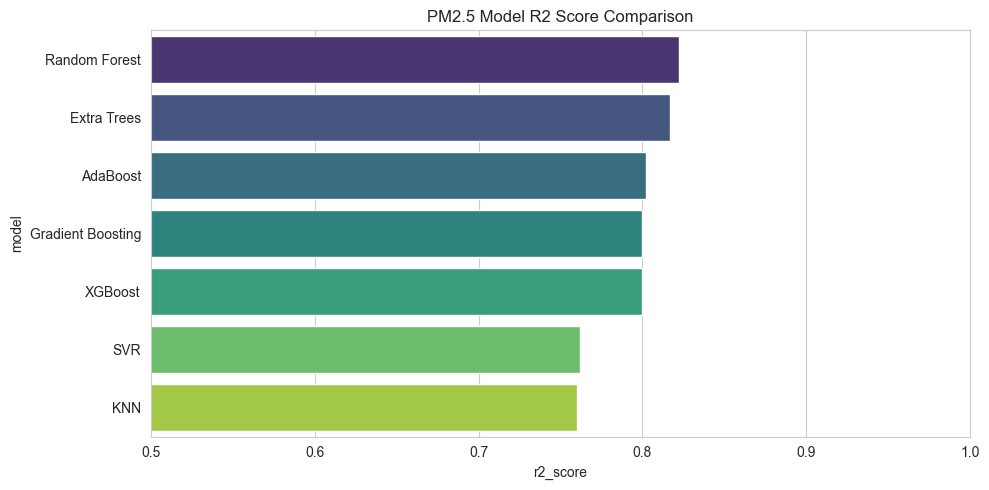

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="r2_score", y="model", palette="viridis")
plt.title("PM2.5 Model R2 Score Comparison")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()